In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from torch.amp import GradScaler, autocast

# для colab способ 1
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copy('/content/drive/MyDrive/model.py', '/content/model.py')

# для colab способ 2
# from google.colab import drive
# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive')

from model import SASRecModel, negative_sampling_loss

In [2]:
data = torch.load('preprocessed_data.pt')

# для colab
# data = torch.load('/content/drive/MyDrive/preprocessed_data.pt')

C:\Users\1\AppData\Local\Temp\ipykernel_11964\2643031679.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('preprocessed_data.pt')


In [3]:
train_inputs, train_targets, train_weights = data['train_inputs'], data['train_targets'], data['train_weights']
validate_inputs, validate_targets = data['validate_inputs'], data['validate_targets']
cnt_item = data['cnt_item']

print(f"Train: {len(train_inputs)} примеров")
print(f"Validate: {len(validate_inputs)} примеров")

Train: 305682 примеров
Validate: 65590 примеров


In [4]:
def ndcg_at_k(rel, pred, k=10):
    # метрика NDCG@k
    ndcg = 0.0
    if rel in pred[:k]:
        pred_list = list(pred[:k])
        score = pred_list.index(rel) + 1
        ndcg = 1.0 / np.log2(score + 1)
        return ndcg
    return ndcg


def recall_at_k(rel, pred, k=10):
    # метрика Recall@k
    recall = 1.0 if rel in pred[:k] else 0.0
    return recall

In [5]:
batch_size = 32
train_dataset = TensorDataset(train_inputs, train_targets, train_weights)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [7]:
def check_metrics_validate(model, validate_inputs, validate_targets, k=10, batch_size=16):
    # расчет метрик на валидационной выборке
    model.eval()
    ndcg_scores, recall_scores = [], []

    with torch.no_grad():
        for i in tqdm(range(0, len(validate_inputs), batch_size), desc="Validate"):
            batch_input = validate_inputs[i:i+batch_size].to(device)
            batch_target = validate_targets[i:i+batch_size]

            logits = model(batch_input)
            scores = logits[:, -1, :]
            _, pred = torch.topk(scores, k=k, dim=1)
            pred = pred.cpu().numpy()

            for j in range(len(batch_target)):
              target = batch_target[j].item()
              ndcg_scores.append(ndcg_at_k(target, pred[j], k))
              recall_scores.append(recall_at_k(target, pred[j], k))

    model.train()
    return np.mean(ndcg_scores), np.mean(recall_scores)

In [8]:
# Эксперимент 1 — Weight Decay

model_exp1 = SASRecModel(cnt_item=cnt_item).to(device)
optimizer = torch.optim.Adam(model_exp1.parameters(), lr=0.001, weight_decay=1e-4)
scaler = GradScaler('cuda')
os.makedirs('checkpoints', exist_ok=True)

best_ndcg = 0.0
#проверяем метрики на валидации каждые 2 эпохи
check_validate = 2
patience = 2
patience_counter = 0

# для графиков
history_exp1 = {
    'epoch': [],
    'train_loss': [],
    'validate_ndcg': [],
    'validate_recall': []
}

for epoch in range(1, 13):
    # обучение
    model_exp1.train()
    total_loss = 0

    for inputs, targets, weights in tqdm(train_loader, desc=f"Exp1 Epoch {epoch}/12"):
        inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)

        with autocast('cuda'):
            logits = model_exp1(inputs)
            loss = negative_sampling_loss(logits[:, -1, :], targets, weights, cnt_item)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history_exp1['epoch'].append(epoch)
    history_exp1['train_loss'].append(avg_loss)

    if epoch % 2 == 0:
        validate_ndcg, validate_recall = check_metrics_validate(model_exp1, validate_inputs, validate_targets, k=10, batch_size=32)
        history_exp1['validate_ndcg'].append(validate_ndcg)
        history_exp1['validate_recall'].append(validate_recall)

        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f} | Validate NDCG@10: {validate_ndcg:.4f} | Validate Recall@10: {validate_recall:.4f}', flush=True)

        if validate_ndcg > best_ndcg:
            best_ndcg = validate_ndcg
            patience_counter = 0
            torch.save(model_exp1.state_dict(), 'checkpoints/sasrec_exp1.pth')
            print(f'Лучшая модель сохранена (NDCG@10: {best_ndcg:.4f})', flush=True)
        else:
            patience_counter += 1
            print(f'Нет улучшения ({patience_counter}/{patience})', flush=True)
        if patience_counter >= patience:
            print(f'Ранняя остановка на эпохе {epoch}', flush=True)
            break
    else:
        history_exp1['validate_ndcg'].append(None)
        history_exp1['validate_recall'].append(None)
        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f}', flush=True)

exp1_best_ndcg = best_ndcg
print(f'Эксперимент 1 — лучшая NDCG@10: {exp1_best_ndcg:.4f}\n')

Exp1 Epoch 1/12: 100%|██████████| 9553/9553 [14:29<00:00, 10.99it/s]

Epoch  1 | Train Loss: 6.0440



Validate: 100%|██████████| 2050/2050 [09:51<00:00,  3.47it/s]

Epoch  2 | Train Loss: 3.3596 | Validate NDCG@10: 0.0047 | Validate Recall@10: 0.0096


Лучшая модель сохранена (NDCG@10: 0.0047)


...


Exp1 Epoch 11/12: 100%|██████████| 9553/9553 [14:37<00:00, 10.89it/s]

Epoch 11 | Train Loss: 2.7970



Validate: 100%|██████████| 2050/2050 [09:16<00:00,  3.68it/s]

Epoch 12 | Train Loss: 2.7744 | Validate NDCG@10: 0.0075 | Validate Recall@10: 0.0148


Лучшая модель сохранена (NDCG@10: 0.0075)
Эксперимент 1 — лучшая NDCG@10: 0.0075



In [9]:
#from google.colab import files
#files.download('checkpoints/sasrec_exp1.pth')

In [10]:
# Эксперимент 2 — dropout=0.3

model_exp2 = SASRecModel(cnt_item=cnt_item, dropout=0.3).to(device)
optimizer = torch.optim.Adam(model_exp2.parameters(), lr=0.001)
scaler = GradScaler('cuda')

best_ndcg = 0.0
#проверяем метрики на валидации каждые 2 эпохи
check_validate = 2
patience = 2
patience_counter = 0

# для графиков
history_exp2 = {
    'epoch': [],
    'train_loss': [],
    'validate_ndcg': [],
    'validate_recall': []
}

for epoch in range(1, 13):
    # обучение
    model_exp2.train()
    total_loss = 0

    for inputs, targets, weights in tqdm(train_loader, desc=f"Exp2 Epoch {epoch}/12"):
        inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)

        with autocast('cuda'):
            logits = model_exp2(inputs)
            loss = negative_sampling_loss(logits[:, -1, :], targets, weights, cnt_item)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history_exp2['epoch'].append(epoch)
    history_exp2['train_loss'].append(avg_loss)

    if epoch % 2 == 0:
      validate_ndcg, validate_recall = check_metrics_validate(model_exp2, validate_inputs, validate_targets, k=10, batch_size=32)
      history_exp2['validate_ndcg'].append(validate_ndcg)
      history_exp2['validate_recall'].append(validate_recall)

      print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f} | Validate NDCG@10: {validate_ndcg:.4f} | Validate Recall@10: {validate_recall:.4f}', flush=True)

      if validate_ndcg > best_ndcg:
        best_ndcg = validate_ndcg
        patience_counter = 0
        torch.save(model_exp2.state_dict(), 'checkpoints/sasrec_exp2.pth')
        print(f'Лучшая модель сохранена (NDCG@10: {best_ndcg:.4f})', flush=True)
      else:
        patience_counter += 1
        print(f'Нет улучшения ({patience_counter}/{patience})', flush=True)

      if patience_counter >= patience:
        print(f'Ранняя остановка на эпохе {epoch}', flush=True)
        break

    else:
      history_exp2['validate_ndcg'].append(None)
      history_exp2['validate_recall'].append(None)
      print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f}', flush=True)

exp2_best_ndcg = best_ndcg
print(f'Эксперимент 2 — лучшая NDCG@10: {exp2_best_ndcg:.4f}\n')

Exp2 Epoch 1/12: 100%|██████████| 9553/9553 [23:49<00:00,  6.69it/s]

Epoch  1 | Train Loss: 5.8177



Validate: 100%|██████████| 2050/2050 [09:28<00:00,  3.61it/s]

Epoch  2 | Train Loss: 2.9061 | Validate NDCG@10: 0.0055 | Validate Recall@10: 0.0105


Лучшая модель сохранена (NDCG@10: 0.0055)


...

Exp2 Epoch 11/12: 100%|██████████| 9553/9553 [38:14<00:00,  4.16it/s]  

Epoch 11 | Train Loss: 1.1662



Validate: 100%|██████████| 2050/2050 [13:45<00:00,  2.48it/s]

Epoch 12 | Train Loss: 1.0299 | Validate NDCG@10: 0.0121 | Validate Recall@10: 0.0231


Лучшая модель сохранена (NDCG@10: 0.0121)
Эксперимент 2 — лучшая NDCG@10: 0.0121



In [1]:
#from google.colab import files
#files.download('checkpoints/sasrec_exp2.pth')

In [12]:
print(f'Эксперимент 1 (Weight Decay): NDCG@10 = {exp1_best_ndcg:.4f}')
print(f'Эксперимент 2 (dropout=0.3):  NDCG@10 = {exp2_best_ndcg:.4f}')

Эксперимент 1 (Weight Decay): NDCG@10 = 0.0075
Эксперимент 2 (dropout=0.3):  NDCG@10 = 0.0121


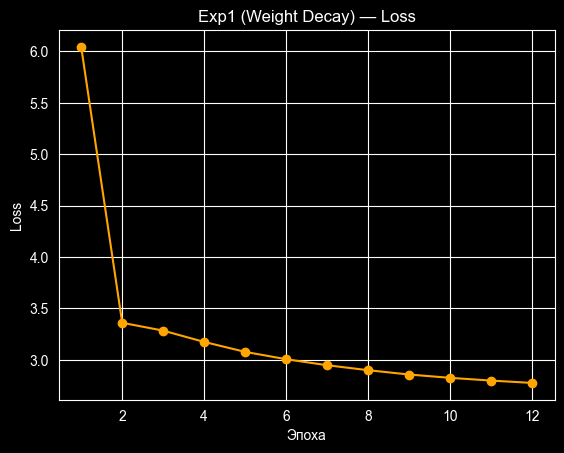

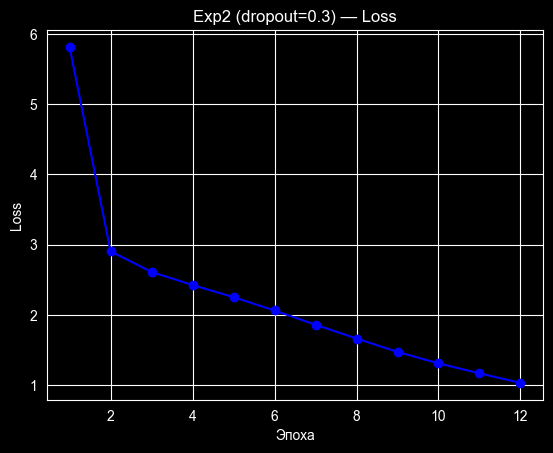

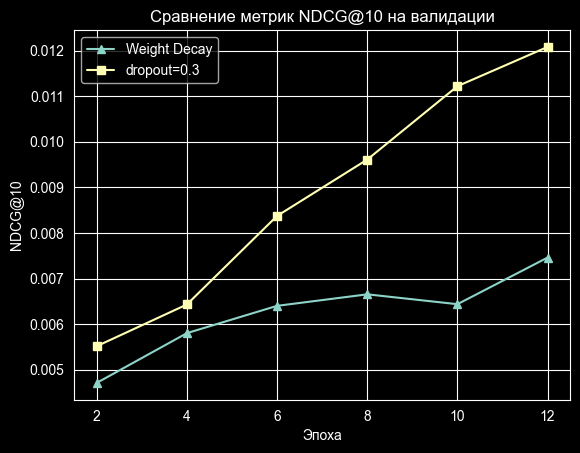

In [13]:
# loss эксперимента 1
plt.figure()
plt.plot(history_exp1['epoch'], history_exp1['train_loss'], marker='o', color='orange')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Exp1 (Weight Decay) — Loss')
plt.grid(True)
plt.show()

# loss эксперимента 2
plt.figure()
plt.plot(history_exp2['epoch'], history_exp2['train_loss'], marker='o', color='blue')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Exp2 (dropout=0.3) — Loss')
plt.grid(True)
plt.show()

# NDCG
validate_epochs_exp1 = [e for e, i in zip(history_exp1['epoch'], history_exp1['validate_ndcg']) if i is not None]
validate_ndcg_exp1 = [i for i in history_exp1['validate_ndcg'] if i is not None]
validate_epochs_exp2 = [e for e, i in zip(history_exp2['epoch'], history_exp2['validate_ndcg']) if i is not None]
validate_ndcg_exp2 = [i for i in history_exp2['validate_ndcg'] if i is not None]

plt.figure()
plt.plot(validate_epochs_exp1, validate_ndcg_exp1, marker='^', label='Weight Decay')
plt.plot(validate_epochs_exp2, validate_ndcg_exp2, marker='s', label='dropout=0.3')
plt.xlabel('Эпоха')
plt.ylabel('NDCG@10')
plt.title('Сравнение метрик NDCG@10 на валидации')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# оценка на тесте

test_inputs = data['test_inputs']
test_targets = data['test_targets']
k_values = [10, 50, 100]

models_dict = {
    'Weight Decay': ('checkpoints/sasrec_exp1.pth', SASRecModel(cnt_item=cnt_item).to(device)),
    'Dropout 0.3': ('checkpoints/sasrec_exp2.pth', SASRecModel(cnt_item=cnt_item, dropout=0.3).to(device))
}

for name, (path, mdl) in models_dict.items():
    try:
        mdl.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        mdl.eval()
        ndcg_scores = {k: [] for k in k_values}
        recall_scores = {k: [] for k in k_values}
        with torch.no_grad():
            for i in tqdm(range(len(test_inputs)), desc=name, leave=False):
                inp = test_inputs[i].unsqueeze(0).to(device)
                target = test_targets[i].item()
                scores = mdl(inp)[0, -1, :]
                _, pred = torch.topk(scores, k=max(k_values), dim=0)
                pred = pred.cpu().numpy()
                for k in k_values:
                    ndcg_scores[k].append(ndcg_at_k(target, pred, k))
                    recall_scores[k].append(recall_at_k(target, pred, k))
        print(f'\n{name}:')
        for k in k_values:
            print(f'NDCG@{k:<3}   {np.mean(ndcg_scores[k]):.4f}')
            print(f'Recall@{k:<3} {np.mean(recall_scores[k]):.4f}')
    except FileNotFoundError:
        print(f'\n{name}: модель не найдена ({path})')


Weight Decay:
NDCG@10    0.0072
Recall@10  0.0149
NDCG@50    0.0155
Recall@50  0.0542
NDCG@100   0.0209
Recall@100 0.0873



Dropout 0.3:
NDCG@10    0.0121
Recall@10  0.0226
NDCG@50    0.0208
Recall@50  0.0635
NDCG@100   0.0261
Recall@100 0.0963
